# Milestone 3: Feature Prioritization using RICE

In [1]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


### Top 8 features based on prior analysis
1.	Wearable Integration	
2.	Social Features	        
3.	Progress Photos	        
4.	Meal Planning	       
5.	Offline Mode	      
6.	Water Tracking
7.  Dark Mode
8.  Export Data

The rest of the 2 Feature Requests had 0 counts, so omitted as they would simple return 0

### Reach Estimation
#### using Review Mentions

In [2]:
total_users = 50000
quarters = 4
total_reviews = 37427

#### Caculating Reach for each
data = {
    "Feature": [
        "Wearable Integration",
        "Social Features",
        "Progress Photos",
        "Meal Planning",
        "Offline Mode",
        "Water Tracking",
        "Dark Mode",
        "Export Data"
    ],
    "Mentions": [368, 296, 214, 67, 45, 25, 9, 8]
}
df = pd.DataFrame(data)
reach_series = ((df["Mentions"] / total_reviews) * total_users * quarters).round()
print(reach_series)


0    1966.0
1    1582.0
2    1144.0
3     358.0
4     240.0
5     134.0
6      48.0
7      43.0
Name: Mentions, dtype: float64


### Impact Estimation:

In [3]:
# There is no negative sentiment that could be found from M2 analysis
# and the average sentiment ranged between 0.03 to 0.30
impact_series = pd.Series([1.0,0.5,0.5,0.5,1.0,0.25,0.25,0.5])
print(impact_series)

0    1.00
1    0.50
2    0.50
3    0.50
4    1.00
5    0.25
6    0.25
7    0.50
dtype: float64


### Confidence Estimation

In [4]:
#Creating a confidence series based on M2
confidence_series = pd.Series([1.0,1.0,1.0,0.8,0.8,0.5,0.5,0.5])
print(confidence_series)

0    1.0
1    1.0
2    1.0
3    0.8
4    0.8
5    0.5
6    0.5
7    0.5
dtype: float64


### Effort Estimation:

In [5]:
### Effort Estimation:
effort_series = pd.Series([3,4.0,1.0,4.0,2,1.5,0.5,1.5])
print(effort_series)

0    3.0
1    4.0
2    1.0
3    4.0
4    2.0
5    1.5
6    0.5
7    1.5
dtype: float64


###  RICE Scores

In [6]:
df["Reach"] = reach_series
df["Impact"] = impact_series
df["Confidence"] = confidence_series
df["Effort"] = effort_series

# Calculate RICE Score
df["RICE Score"] = (
    (df["Reach"] * df["Impact"] * df["Confidence"]) / df["Effort"]
)

# Rank (1 = highest priority)
df["Rank"] = df["RICE Score"].rank(ascending=False, method="dense").astype(int)
rice_df = df[[
    "Feature",
    "Reach",
    "Impact",
    "Confidence",
    "Effort",
    "RICE Score",
    "Rank"
]].sort_values(by="Rank")
rice_df

,Feature,Reach,Impact,Confidence,Effort,RICE Score,Rank
0,Wearable Integration,1966.0,1.00,1.0,3.0,655.333333,1
2,Progress Photos,1144.0,0.50,1.0,1.0,572.000000,2
1,Social Features,1582.0,0.50,1.0,4.0,197.750000,3
4,Offline Mode,240.0,1.00,0.8,2.0,96.000000,4
3,Meal Planning,358.0,0.50,0.8,4.0,35.800000,5
6,Dark Mode,48.0,0.25,0.5,0.5,12.000000,6
5,Water Tracking,134.0,0.25,0.5,1.5,11.166667,7
7,Export Data,43.0,0.50,0.5,1.5,7.166667,8


In [7]:
developers = 5
months = 6
available_capacity = 10
priority_df = rice_df.sort_values(by="Rank").head(5)
total_effort_top5 = priority_df["Effort"].sum()
print(total_effort_top5)

14.0


In [8]:
print("Available Capacity:", available_capacity)
print("Total Effort (Top 5):", total_effort_top5)

if total_effort_top5 <= available_capacity:
    print("\n✅ All Top 5 Features Can Be Built")
    selected_features = top_5.copy()
else:
    print("\n Cannot build all Top 5. Selecting highest priority within capacity...\n")
    
    selected_features = pd.DataFrame(columns=priority_df.columns)
    remaining_capacity = available_capacity
    
    for _, row in priority_df.iterrows():
        if row["Effort"] <= remaining_capacity:
            selected_features = pd.concat(
                [selected_features, row.to_frame().T],
                ignore_index=True
            )
            remaining_capacity -= row["Effort"]
    
print("\nSelected Features Within Capacity:")
print(selected_features[[
    "Feature", "Effort", "RICE Score", "Rank"
]])

Available Capacity: 10
Total Effort (Top 5): 14.0

 Cannot build all Top 5. Selecting highest priority within capacity...


Selected Features Within Capacity:
                Feature Effort  RICE Score Rank
0  Wearable Integration    3.0  655.333333    1
1       Progress Photos    1.0       572.0    2
2       Social Features    4.0      197.75    3
3          Offline Mode    2.0        96.0    4


### Visualizations

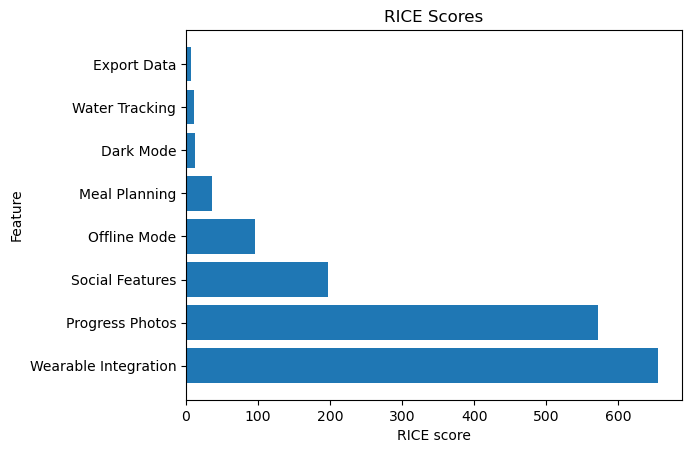

In [9]:
# Rice Score 
plt.barh(rice_df['Feature'], rice_df['RICE Score'])
plt.title('RICE Scores')
plt.xlabel("RICE score")
plt.ylabel("Feature")
plt.show()


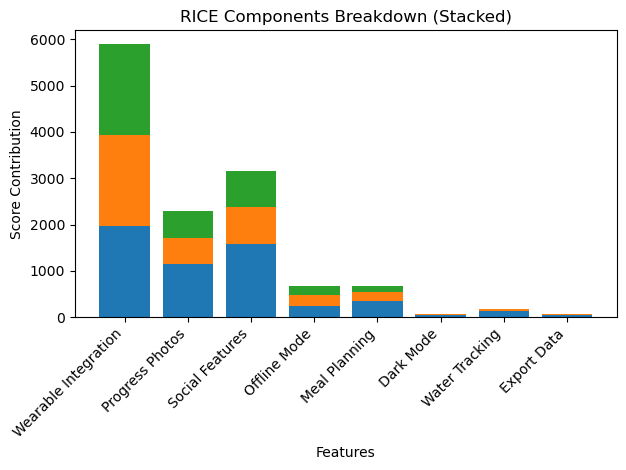

In [12]:
# Rice components

# Calculate stacked components
reach_component = rice_df["Reach"]
impact_component = rice_df["Reach"] * rice_df["Impact"]
confidence_component = rice_df["Reach"] * rice_df["Impact"] * rice_df["Confidence"]

x = np.arange(len(rice_df))

plt.figure()

# Base Reach
plt.bar(x, reach_component)

# Reach × Impact stacked on top of Reach
plt.bar(x, impact_component, bottom=reach_component)

# Reach × Impact × Confidence stacked on top
plt.bar(x, confidence_component, bottom=reach_component + impact_component)

plt.xticks(x, rice_df["Feature"], rotation=45, ha="right")
plt.ylabel("Score Contribution")
plt.xlabel("Features")
plt.title("RICE Components Breakdown (Stacked)")

plt.tight_layout()
plt.show()

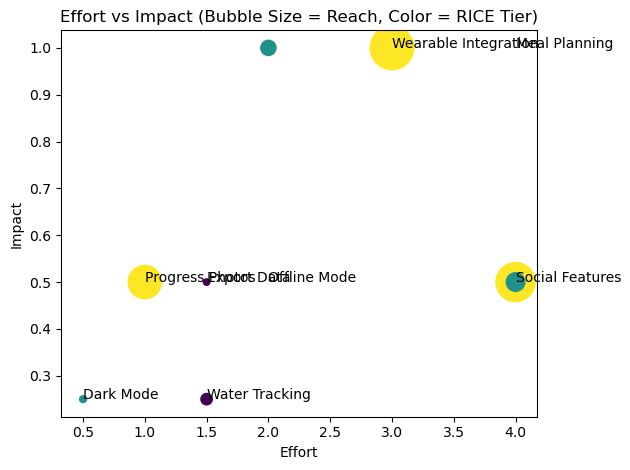

In [13]:
# Effort vs. Impact:

rice_df = rice_df.sort_values("RICE Score", ascending=False).reset_index(drop=True)
n = len(rice_df)

rice_df["RICE Tier"] = pd.cut(
    rice_df.index,
    bins=[-1, n/3, 2*n/3, n],
    labels=["High", "Medium", "Low"]
)

tier_map = {"High": 3, "Medium": 2, "Low": 1}
rice_df["Tier_Code"] = rice_df["RICE Tier"].map(tier_map)


plt.figure()

plt.scatter(
    rice_df["Effort"],
    rice_df["Impact"],
    s=rice_df["Reach"] / 2,      # Bubble size scaled
    c=rice_df["Tier_Code"]       # Color by tier
)

plt.xlabel("Effort")
plt.ylabel("Impact")
plt.title("Effort vs Impact (Bubble Size = Reach, Color = RICE Tier)")

for i in range(len(rice_df)):
    plt.annotate(
        rice_df["Feature"][i],
        (rice_df["Effort"][i], df["Impact"][i])
    )

plt.tight_layout()
plt.show()

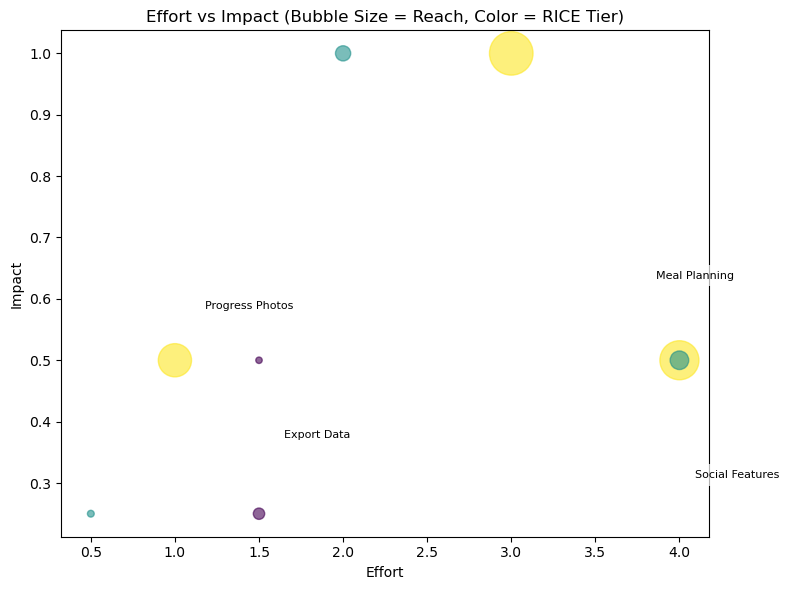

In [17]:
rice_df = rice_df.sort_values("RICE Score", ascending=False).reset_index(drop=True)
n = len(rice_df)

rice_df["RICE Tier"] = pd.cut(
    rice_df.index,
    bins=[-1, n/3, 2*n/3, n],
    labels=["High", "Medium", "Low"]
)

tier_map = {"High": 3, "Medium": 2, "Low": 1}
rice_df["Tier_Code"] = rice_df["RICE Tier"].map(tier_map)

plt.figure(figsize=(8, 6))

plt.scatter(
    rice_df["Effort"],
    rice_df["Impact"],
    s=rice_df["Reach"] / 2,
    c=rice_df["Tier_Code"],
    alpha=0.6
)

plt.xlabel("Effort")
plt.ylabel("Impact")
plt.title("Effort vs Impact (Bubble Size = Reach, Color = RICE Tier)")

# Slight random offsets to reduce overlap
np.random.seed(42)
x_offsets = np.random.uniform(-0.2, 0.2, len(rice_df))
y_offsets = np.random.uniform(-0.2, 0.2, len(rice_df))

for i in range(len(rice_df)):
    plt.annotate(
        rice_df["Feature"][i],
        (rice_df["Effort"][i] + x_offsets[i],
         rice_df["Impact"][i] + y_offsets[i]),
        fontsize=8,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
    )

plt.tight_layout()
plt.show()

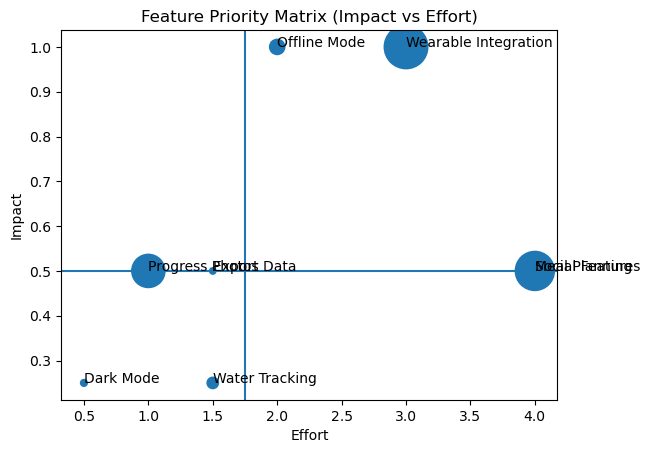

In [18]:
# Feature Priority Matrix

impact_threshold = rice_df["Impact"].median()
effort_threshold = rice_df["Effort"].median()

plt.figure()

# Scatter plot (bubble size = Reach)
plt.scatter(
    rice_df["Effort"],
    rice_df["Impact"],
    s=rice_df["Reach"] / 2
)

# Quadrant divider lines
plt.axhline(impact_threshold)
plt.axvline(effort_threshold)

plt.xlabel("Effort")
plt.ylabel("Impact")
plt.title("Feature Priority Matrix (Impact vs Effort)")

# Annotate feature names
for i in range(len(df)):
    plt.annotate(
        rice_df["Feature"][i],
        (rice_df["Effort"][i], rice_df["Impact"][i])
    )

#plt.tight_layout()
plt.show()


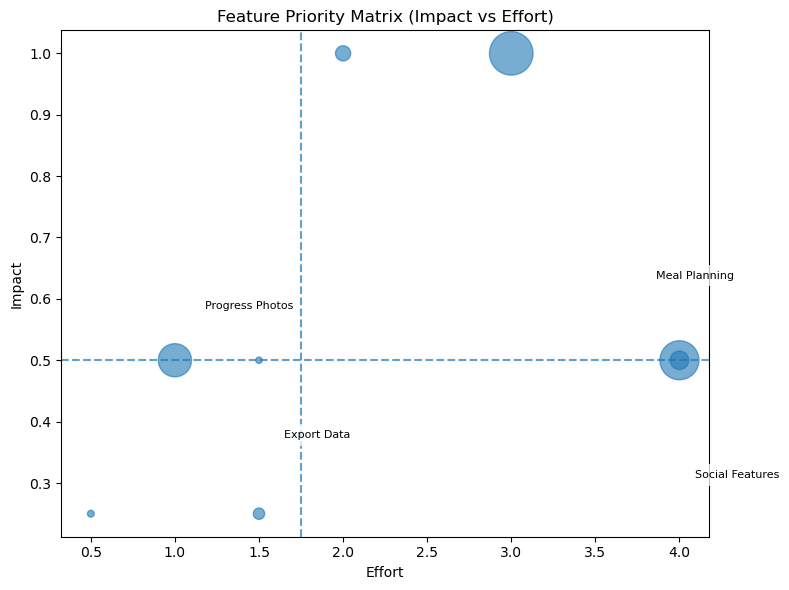

In [20]:
impact_threshold = rice_df["Impact"].median()
effort_threshold = rice_df["Effort"].median()

plt.figure(figsize=(8, 6))

# Scatter plot (bubble size = Reach)
plt.scatter(
    rice_df["Effort"],
    rice_df["Impact"],
    s=rice_df["Reach"] / 2,
    alpha=0.6
)

# Quadrant divider lines
plt.axhline(impact_threshold, linestyle='--', alpha=0.7)
plt.axvline(effort_threshold, linestyle='--', alpha=0.7)

plt.xlabel("Effort")
plt.ylabel("Impact")
plt.title("Feature Priority Matrix (Impact vs Effort)")

# Small random offsets to reduce label overlap
np.random.seed(42)
x_offsets = np.random.uniform(-0.2, 0.2, len(rice_df))
y_offsets = np.random.uniform(-0.2, 0.2, len(rice_df))

# Annotate feature names
for i in range(len(rice_df)):
    plt.annotate(
        rice_df["Feature"][i],
        (
            rice_df["Effort"][i] + x_offsets[i],
            rice_df["Impact"][i] + y_offsets[i]
        ),
        fontsize=8,
        bbox=dict(facecolor='white', alpha=0.75, edgecolor='none')
    )

plt.tight_layout()
plt.show()

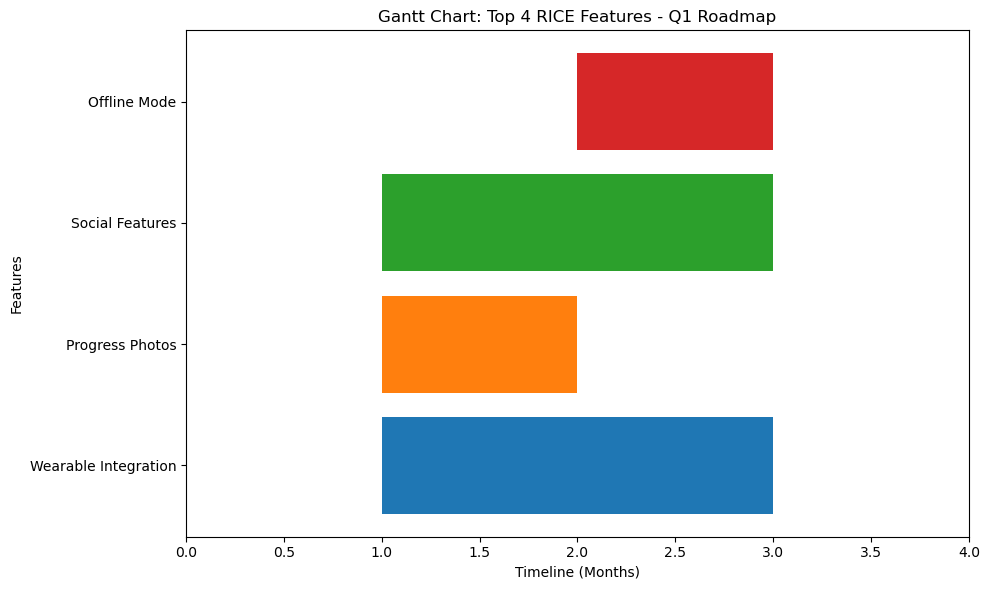

In [9]:

# Data for Top 4 Features (Quarter 1)
features = [
    "Wearable Integration",
    "Progress Photos",
    "Social Features",
    "Offline Mode"
]

# Start month and duration (in months)
start_times = [1, 1, 1, 2]
durations = [2, 1, 2, 1]

plt.figure(figsize=(10, 6))

# Create Gantt bars
for i in range(len(features)):
    plt.barh(
        features[i],
        durations[i],
        left=start_times[i]
    )

plt.xlabel("Timeline (Months)")
plt.ylabel("Features")
plt.title("Gantt Chart: Top 4 RICE Features - Q1 Roadmap")

plt.xlim(0, 4)
plt.tight_layout()
plt.show()
